# LEAF Batch Processing – DE-Har 2025

Processes all LEAF scans for the year, merges with meteorological data, and saves structured output files for downstream analysis.

**Output: one parquet file per scan type:**
- `leaf_hemi_hi_2025.parquet`
- `leaf_hemi_low_2025.parquet`
- `leaf_hinge_2025.parquet`

**Each file has one row per (scan × height bin) in long format:**

| Column group | Columns |
|---|---|
| Identity | `datetime`, `scan_hour`, `filename`, `height` |
| Plant profiles | `HingePAI`, `LinearPAI`, `WeightedPAI`, `HingePAVD`, `LinearPAVD`, `WeightedPAVD`, `LinearMLA` |
| Pgap profiles | `Pgap_Z07.5`, `Pgap_Z12.5`, ... (one per zenith bin) |
| Met context | `tair_c`, `rh_pct`, `vpd_hpa`, `ustar_ms`, `precip_mm` |
| Quality flags | `flag_rain`, `flag_humid`, `flag_wind`, `quality_good` |

**Downstream usage** — simple pandas filtering:
```python
df = pd.read_parquet('leaf_hemi_hi_2025.parquet')
predawn_clean = df[(df.scan_hour == 5) & df.quality_good]
pgap_10m = predawn_clean[predawn_clean.height == 10.0]
```

In [1]:
import os
import re
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import importlib
assert importlib.util.find_spec("pyarrow") is not None, \
    "pyarrow not installed — run: conda install pyarrow"

from pylidar_tls_canopy import leaf_io, plant_profile

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

RIEGL RDBlib is not available
RIEGL RiVlib is not available


In [2]:
# ── Pre-flight checks ──────────────────────────────────────────────
import sys, importlib

errors = []

# 1. Required packages
for pkg in ['pyarrow', 'numpy', 'pandas', 'pylidar_tls_canopy']:
    if importlib.util.find_spec(pkg) is None:
        errors.append(f'Missing package: {pkg}  →  pip install {pkg}')

# 2. pyarrow/pandas compatibility (the actual serialization)
if not errors:
    try:
        import pandas as pd
        import pyarrow
        test_df = pd.DataFrame({'a': [1, 2], 'b': [3.0, 4.0], 'c': [True, False]})
        test_df.to_parquet('/tmp/_preflight_test.parquet', index=False)
        pd.read_parquet('/tmp/_preflight_test.parquet')
        import os; os.remove('/tmp/_preflight_test.parquet')
    except Exception as e:
        errors.append(f'Parquet round-trip FAILED: {e}\n'
                      f'  → pip install --upgrade pyarrow\n'
                      f'  Installed: pandas={pd.__version__}, pyarrow={pyarrow.__version__}')

# 3. Output directory exists
from pathlib import Path
out_dir = Path('../../data/processed/proximal_rs')
if not out_dir.exists():
    errors.append(f'Output dir missing: {out_dir}  →  mkdir -p {out_dir}')

# 4. Input data exists
data_dir = Path('../../data/raw/proximal_rs/leaf')
n_files = len(list(data_dir.glob('ESS?????_*_hemi_*_0800_0400.csv')))
if n_files == 0:
    errors.append(f'No LEAF scan files found in {data_dir}')

if errors:
    print('✗ PRE-FLIGHT FAILED:')
    for e in errors:
        print(f'  • {e}')
    raise RuntimeError('Fix the above before running the pipeline.')
else:
    print(f'✓ All checks passed ({n_files} scan files, parquet OK)')

✓ All checks passed (1940 scan files, parquet OK)


## 1. Settings

In [3]:
# --- Paths ---
PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "proximal_rs" / "leaf"
MET_FILE = PROJECT_ROOT / "data/processed/atmosphere_soil/meteo_dehar_30min.csv"
PRECIP_FILE = PROJECT_ROOT / "data/processed/atmosphere_soil/HARTHM_2025_Precipitation_30min_UTC.csv"
OUT_DIR = PROJECT_ROOT / "data/processed/proximal_rs/leaf"
OUT_DIR.mkdir(exist_ok=True)

# --- Instrument ---
SENSOR_HEIGHT = 1.5
ZENITH_OFFSET = 0

# --- Profile parameters ---
HRES = 0.5
MAX_H = 25
MIN_ZENITH = 5
MAX_ZENITH = 70
ZRES = 5
ARES = 45
METHOD = 'FIRSTLAST'

# --- Quality thresholds ---
PRECIP_WINDOW_H = 3
PRECIP_THRESH_MM = 0.1
RH_THRESH_PCT = 95
USTAR_THRESH_MS = 0.7
SCAN_DURATIONS = {'hemi_hi': 45, 'hemi_low': 8, 'hinge': 6}  # minutes

## 2. Load meteorological data

In [4]:
met = pd.read_csv(MET_FILE, parse_dates=['datetime'])
met['datetime'] = pd.to_datetime(met['datetime'], utc=True)
met = met.set_index('datetime').sort_index()

precip = pd.read_csv(PRECIP_FILE)
precip['datetime'] = pd.to_datetime(precip['From'].str.replace('Z', '+00:00'), utc=True)
precip = precip.set_index('datetime')[['Precipitation_Sum_mm']].sort_index()

met_full = met.join(precip, how='outer')
met_full['Precipitation_Sum_mm'] = met_full['Precipitation_Sum_mm'].fillna(0)

print(f'Met: {met_full.index.min()} → {met_full.index.max()}')
print(f'Columns: {list(met_full.columns)}')

Met: 2024-11-30 23:30:00+00:00 → 2025-12-31 23:30:00+00:00
Columns: ['tair_c', 'rh_pct', 'vpd_hpa', 'rg_wm2', 'par_umol_m2s', 'ustar_ms', 'Precipitation_Sum_mm']


## 3. Helper functions

In [7]:
def get_scan_datetime(filepath):
    """Extract UTC datetime from LEAF filename."""
    m = re.search(r'(\d{8})-(\d{6})Z', filepath.name)
    if m:
        return datetime.datetime.strptime(m.group(1) + m.group(2), '%Y%m%d%H%M%S')
    return None


def get_met_context(scan_dt, met_df, duration_min=45):
    """Extract met conditions during and before a scan.
    
    Returns dict with met values and quality flags.
    """
    scan_start = pd.Timestamp(scan_dt, tz='UTC')
    scan_end = scan_start + pd.Timedelta(minutes=duration_min)
    precip_start = scan_start - pd.Timedelta(hours=PRECIP_WINDOW_H)
    
    precip_window = met_df.loc[precip_start:scan_end, 'Precipitation_Sum_mm']
    scan_window = met_df.loc[scan_start:scan_end]
    
    if scan_window.empty:
        return {
            'tair_c': np.nan, 'rh_pct': np.nan, 'vpd_hpa': np.nan,
            'ustar_ms': np.nan, 'precip_mm': np.nan,
            'flag_rain': False, 'flag_humid': False, 'flag_wind': False,
            'quality_good': False,
        }
    
    precip_total = precip_window.sum()
    rh_mean = scan_window['rh_pct'].mean()
    ustar_max = scan_window['ustar_ms'].max()
    
    flag_rain = precip_total >= PRECIP_THRESH_MM
    flag_humid = rh_mean >= RH_THRESH_PCT
    flag_wind = ustar_max >= USTAR_THRESH_MS
    
    return {
        'tair_c': scan_window['tair_c'].mean(),
        'rh_pct': rh_mean,
        'vpd_hpa': scan_window['vpd_hpa'].mean(),
        'ustar_ms': ustar_max,
        'precip_mm': precip_total,
        'flag_rain': flag_rain,
        'flag_humid': flag_humid,
        'flag_wind': flag_wind,
        'quality_good': not (flag_rain or flag_humid or flag_wind),
    }


def process_single_scan(filepath, duration_min=45):
    """Process one LEAF scan and return a long-format DataFrame.
    
    Each row = one height bin. Columns include plant profiles,
    Pgap profiles, met context, and quality flags.
    """
    scan_dt = get_scan_datetime(filepath)
    if scan_dt is None:
        return None
    
    # Process profiles
    vpp = plant_profile.Jupp2009(
        hres=HRES, zres=ZRES, ares=ARES,
        min_z=MIN_ZENITH, max_z=MAX_ZENITH,
        min_h=0, max_h=MAX_H)
    
    valid = vpp.add_leaf_scan_position(
        str(filepath), method=METHOD,
        min_zenith=MIN_ZENITH, max_zenith=MAX_ZENITH,
        sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    
    if not valid:
        return None
    
    vpp.get_pgap_theta_z()
    
    # Get both profile tables
    df_plant = vpp.exportPlantProfiles()
    df_pgap = vpp.exportPgapProfiles()
    
    # Merge on Height
    df = df_plant.merge(df_pgap, on='Height')
    df = df.rename(columns={'Height': 'height'})
    
    # Rename Pgap columns for clarity: Zenith0075 → Pgap_Z07.5
    pgap_cols = [c for c in df.columns if c.startswith('Zenith')]
    rename_map = {}
    for c in pgap_cols:
        z_val = float(c.replace('Zenith', '')) / 10
        rename_map[c] = f'Pgap_Z{z_val:05.1f}'
    df = df.rename(columns=rename_map)
    
    # Add scan identity
    df.insert(0, 'datetime', scan_dt)
    df.insert(1, 'scan_hour', scan_dt.hour)
    df.insert(2, 'filename', filepath.name)
    
    # Add met context (same values for all height bins of this scan)
    met_ctx = get_met_context(scan_dt, met_full, duration_min=duration_min)
    for k, v in met_ctx.items():
        df[k] = v
    
    return df

## 4. Discover files

In [8]:
scan_types = {
    'hemi_hi':  {'glob': 'ESS?????_*_hemi_*_0800_0400.csv', 'duration': 45},
    'hemi_low': {'glob': 'ESS?????_*_hemi_*_0200_0100.csv', 'duration': 8},
    'hinge':    {'glob': 'ESS?????_*_hinge_*.csv',           'duration': 6},
}

file_lists = {}
for stype, cfg in scan_types.items():
    files = sorted(DATA_DIR.glob(cfg['glob']))
    file_lists[stype] = files
    
    # Hour distribution
    hours = {}
    for f in files:
        dt = get_scan_datetime(f)
        if dt:
            hours[dt.hour] = hours.get(dt.hour, 0) + 1
    
    print(f'\n{stype}: {len(files)} files')
    for h in sorted(hours):
        print(f'  {h:02d}:00 UTC  {hours[h]:>4d} scans')


hemi_hi: 1940 files
  02:00 UTC   243 scans
  05:00 UTC   243 scans
  08:00 UTC   243 scans
  11:00 UTC   241 scans
  14:00 UTC   242 scans
  17:00 UTC   242 scans
  20:00 UTC   243 scans
  23:00 UTC   243 scans

hemi_low: 1939 files
  00:00 UTC   243 scans
  03:00 UTC   243 scans
  06:00 UTC   243 scans
  09:00 UTC   241 scans
  12:00 UTC   242 scans
  15:00 UTC   241 scans
  18:00 UTC   243 scans
  21:00 UTC   243 scans

hinge: 1459 files
  01:00 UTC   243 scans
  07:00 UTC   243 scans
  10:00 UTC   242 scans
  11:00 UTC     1 scans
  13:00 UTC   243 scans
  15:00 UTC     1 scans
  19:00 UTC   243 scans
  22:00 UTC   243 scans


## 5. Batch processing

Process all scans per type and concatenate into one DataFrame per scan type.

In [7]:
for stype, files in file_lists.items():
    duration = scan_types[stype]['duration']
    outfile = OUT_DIR / f'leaf_{stype}_2025.parquet'
    
    print(f'\n{"=" * 60}')
    print(f'Processing {stype}: {len(files)} files → {outfile.name}')
    print(f'{"=" * 60}')
    
    chunks = []
    n_ok = 0
    n_fail = 0
    t0 = time.time()
    
    for i, f in enumerate(files):
        try:
            df = process_single_scan(f, duration_min=duration)
            if df is not None:
                chunks.append(df)
                n_ok += 1
            else:
                n_fail += 1
        except Exception as e:
            print(f'  Error {f.name}: {e}')
            n_fail += 1
        
        if (i + 1) % 100 == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            remaining = (len(files) - i - 1) / rate
            print(f'  {i+1}/{len(files)}  ({n_ok} ok, {n_fail} fail)  '
                  f'{elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining')
    
    if chunks:
        df_all = pd.concat(chunks, ignore_index=True)
        
        # Set proper dtypes
        df_all['datetime'] = pd.to_datetime(df_all['datetime'])
        for col in ['flag_rain', 'flag_humid', 'flag_wind', 'quality_good']:
            df_all[col] = df_all[col].astype(bool)
        
        # Save
        df_all.to_parquet(outfile, index=False)
        
        elapsed = time.time() - t0
        n_scans = df_all['datetime'].nunique()
        n_good = df_all[df_all['height'] == df_all['height'].iloc[0]]['quality_good'].sum()
        print(f'\nDone: {n_scans} scans ({n_good} good quality), '
              f'{len(df_all)} rows, {elapsed:.0f}s')
        print(f'Saved: {outfile} ({outfile.stat().st_size / 1e6:.1f} MB)')
    else:
        print(f'No valid scans for {stype}')


Processing hemi_hi: 1940 files → leaf_hemi_hi_2025.parquet
  100/1940  (100 ok, 0 fail)  43s elapsed, ~783s remaining
  200/1940  (200 ok, 0 fail)  80s elapsed, ~696s remaining
  300/1940  (300 ok, 0 fail)  119s elapsed, ~649s remaining
  400/1940  (400 ok, 0 fail)  157s elapsed, ~604s remaining
  500/1940  (500 ok, 0 fail)  195s elapsed, ~563s remaining
  600/1940  (600 ok, 0 fail)  233s elapsed, ~521s remaining
  700/1940  (700 ok, 0 fail)  271s elapsed, ~480s remaining
  800/1940  (800 ok, 0 fail)  309s elapsed, ~441s remaining
  900/1940  (900 ok, 0 fail)  348s elapsed, ~402s remaining
  1000/1940  (1000 ok, 0 fail)  386s elapsed, ~363s remaining
  1100/1940  (1100 ok, 0 fail)  425s elapsed, ~324s remaining
  1200/1940  (1200 ok, 0 fail)  463s elapsed, ~285s remaining
  1300/1940  (1300 ok, 0 fail)  502s elapsed, ~247s remaining
  1400/1940  (1400 ok, 0 fail)  541s elapsed, ~209s remaining
  1500/1940  (1500 ok, 0 fail)  579s elapsed, ~170s remaining
  1600/1940  (1600 ok, 0 fail)

## 6. Verify output structure

In [9]:
for stype in scan_types:
    fp = OUT_DIR / f'leaf_{stype}_2025.parquet'
    if fp.exists():
        df = pd.read_parquet(fp)
        n_scans = df['datetime'].nunique()
        n_good = df.drop_duplicates('datetime')['quality_good'].sum()
        hours = sorted(df['scan_hour'].unique())
        print(f'\n{stype}: {n_scans} scans ({n_good} good), '
              f'{len(df)} rows, {len(df.columns)} columns')
        print(f'  Heights: {df.height.min():.1f} – {df.height.max():.1f} m '
              f'({df.height.nunique()} bins)')
        print(f'  Hours (UTC): {hours}')
        print(f'  Dates: {df.datetime.min()} → {df.datetime.max()}')
        print(f'  Columns: {list(df.columns)}')
        print(f'  Quality: {n_good}/{n_scans} good '
              f'({n_good/n_scans*100:.0f}%)')


hemi_hi: 1940 scans (1220 good), 97000 rows, 33 columns
  Heights: 0.0 – 24.5 m (50 bins)
  Hours (UTC): [np.int64(2), np.int64(5), np.int64(8), np.int64(11), np.int64(14), np.int64(17), np.int64(20), np.int64(23)]
  Dates: 2025-04-16 20:10:30 → 2025-12-15 08:10:31
  Columns: ['datetime', 'scan_hour', 'filename', 'height', 'HingePAI', 'LinearPAI', 'LinearMLA', 'WeightedPAI', 'HingePAVD', 'LinearPAVD', 'WeightedPAVD', 'Pgap_Z007.5', 'Pgap_Z012.5', 'Pgap_Z017.5', 'Pgap_Z022.5', 'Pgap_Z027.5', 'Pgap_Z032.5', 'Pgap_Z037.5', 'Pgap_Z042.5', 'Pgap_Z047.5', 'Pgap_Z052.5', 'Pgap_Z057.5', 'Pgap_Z062.5', 'Pgap_Z067.5', 'tair_c', 'rh_pct', 'vpd_hpa', 'ustar_ms', 'precip_mm', 'flag_rain', 'flag_humid', 'flag_wind', 'quality_good']
  Quality: 1220/1940 good (63%)

hemi_low: 1939 scans (0 good), 96950 rows, 33 columns
  Heights: 0.0 – 24.5 m (50 bins)
  Hours (UTC): [np.int64(0), np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21)]
  Dates: 2025-04-16 18:10:

---
---
# Usage examples

Everything below demonstrates how to work with the output files. No reprocessing needed.

In [10]:
# Load one file
df = pd.read_parquet(OUT_DIR / 'leaf_hemi_hi_2025.parquet')
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df['week'] = df['datetime'].dt.isocalendar().week.astype(int)
df['month'] = df['datetime'].dt.month
print(f'Loaded: {df.datetime.nunique()} scans, {len(df)} rows')

Loaded: 1940 scans, 97000 rows


### Example 1: Pgap(10m) time series — predawn, quality-filtered

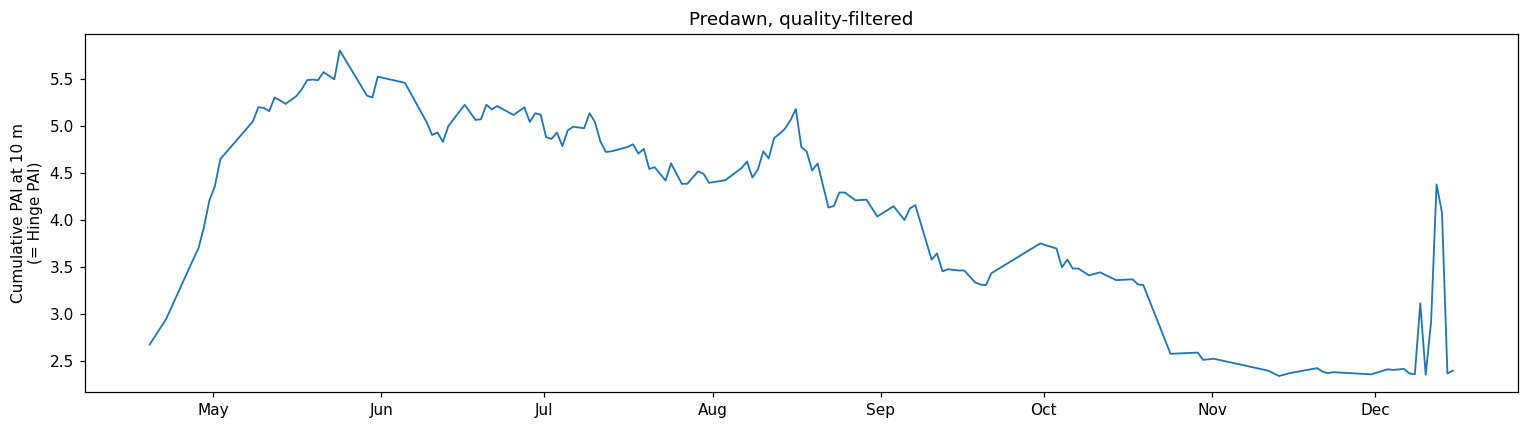

143 observations


In [11]:
# Filter: predawn scans, good quality, single height
pgap_10m = df[(df.scan_hour == 8) & df.quality_good & (df.height == 10.0)].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pgap_10m.datetime, pgap_10m['HingePAI'].values, lw=1.2)
ax.set(ylabel='Cumulative PAI at 10 m\n(= Hinge PAI)', title='Predawn, quality-filtered')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

print(f'{len(pgap_10m)} observations')

### Example 2: Pgap at multiple heights — one line per height

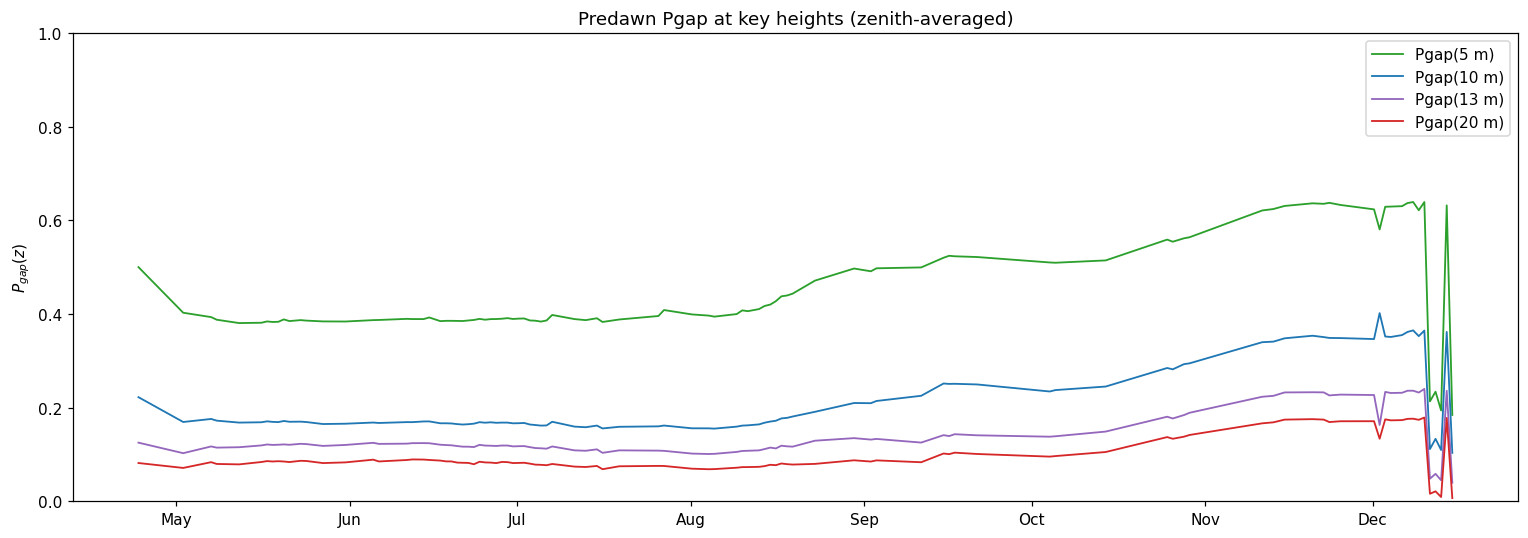

In [12]:
predawn_good = df[(df.scan_hour == 5) & df.quality_good]

fig, ax = plt.subplots(figsize=(14, 5))
for z, color in [(5, '#2ca02c'), (10, '#1f77b4'), (13, '#9467bd'), (20, '#d62728')]:
    subset = predawn_good[predawn_good.height == z]
    # Pgap = average of all zenith Pgap columns at this height
    pgap_cols = [c for c in df.columns if c.startswith('Pgap_Z')]
    pgap_mean = subset[pgap_cols].mean(axis=1)
    ax.plot(subset.datetime, pgap_mean, lw=1.2, color=color, label=f'Pgap({z} m)')

ax.set(ylabel=r'$P_{gap}(z)$', ylim=(0, 1),
       title='Predawn Pgap at key heights (zenith-averaged)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

### Example 3: Weekly PAVD profiles as spaghetti plot

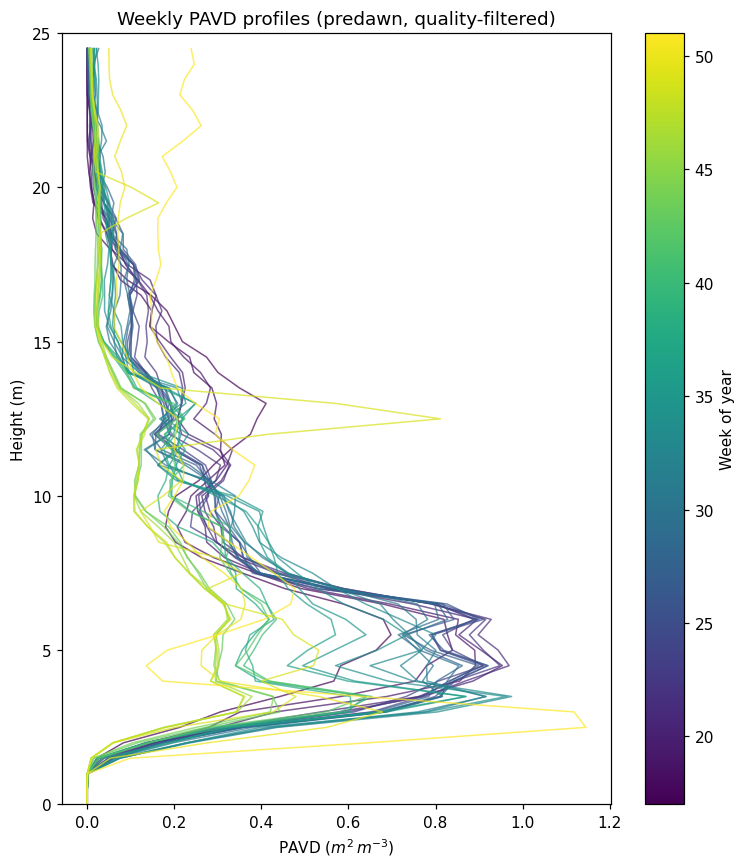

In [13]:
# 05:00 UTC scans, good quality, aggregate by week
predawn_good = df[(df.scan_hour == 5) & df.quality_good].copy()
weekly = predawn_good.groupby(['week', 'height'])['WeightedPAVD'].mean().reset_index()

weeks = sorted(weekly.week.unique())
cmap = plt.cm.viridis
norm = plt.Normalize(min(weeks), max(weeks))

fig, ax = plt.subplots(figsize=(7, 8))
for w in weeks:
    wk = weekly[weekly.week == w]
    ax.plot(wk.WeightedPAVD, wk.height, color=cmap(norm(w)), lw=1, alpha=0.7)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = plt.colorbar(sm, ax=ax, label='Week of year')
ax.set(xlabel=r'PAVD ($m^2\,m^{-3}$)', ylabel='Height (m)',
       title='Weekly PAVD profiles (predawn, quality-filtered)',
       ylim=(0, MAX_H))
plt.tight_layout()
plt.show()

### Example 4: Diurnal comparison — predawn vs afternoon on same day

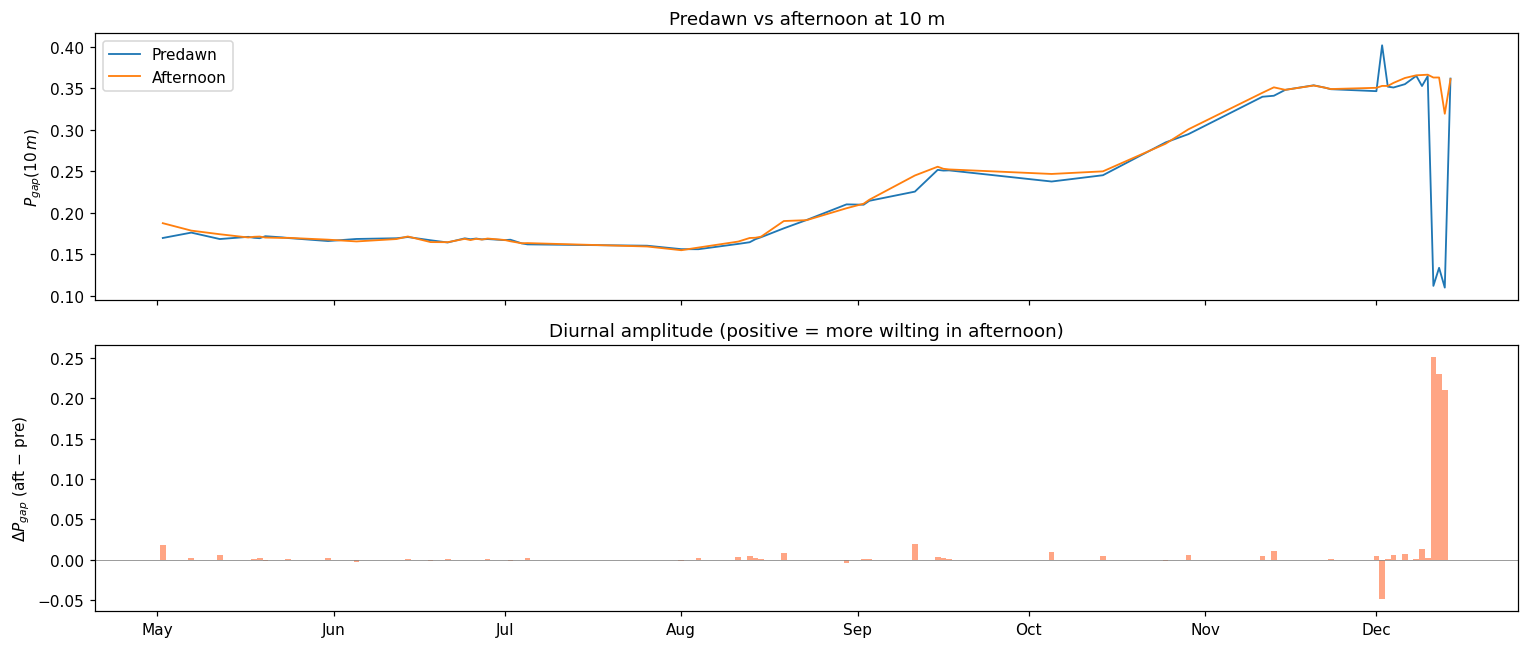

62 matched days


In [14]:
# Get Pgap columns
pgap_cols = [c for c in df.columns if c.startswith('Pgap_Z')]

# Predawn and afternoon, both good quality, at height=10m
pre = df[(df.scan_hour == 5) & df.quality_good & (df.height == 10.0)].copy()
aft = df[(df.scan_hour == 14) & df.quality_good & (df.height == 10.0)].copy()
pre['date'] = pre.datetime.dt.date
aft['date'] = aft.datetime.dt.date

# Merge on date
paired = pre[['date'] + pgap_cols].merge(
    aft[['date'] + pgap_cols], on='date', suffixes=('_pre', '_aft'))

# Mean Pgap across zenith rings
pre_cols = [c + '_pre' for c in pgap_cols]
aft_cols = [c + '_aft' for c in pgap_cols]
paired['pgap_pre'] = paired[pre_cols].mean(axis=1)
paired['pgap_aft'] = paired[aft_cols].mean(axis=1)
paired['delta'] = paired['pgap_aft'] - paired['pgap_pre']
paired['date'] = pd.to_datetime(paired['date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(paired.date, paired.pgap_pre, label='Predawn', lw=1.2)
axes[0].plot(paired.date, paired.pgap_aft, label='Afternoon', lw=1.2)
axes[0].set(ylabel=r'$P_{gap}(10\,m)$', title='Predawn vs afternoon at 10 m')
axes[0].legend()

axes[1].bar(paired.date, paired.delta, width=1, color='coral', alpha=0.7)
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].set(ylabel=r'$\Delta P_{gap}$ (aft − pre)',
            title='Diurnal amplitude (positive = more wilting in afternoon)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

print(f'{len(paired)} matched days')

### Example 5: Filter by VPD threshold

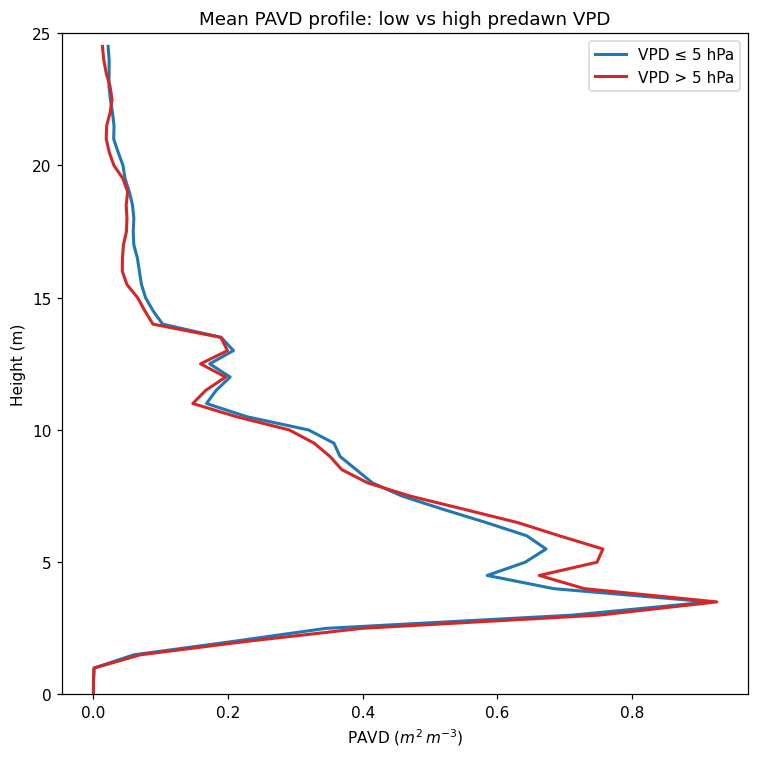

Low VPD: 14 scans
High VPD: 13 scans


In [15]:
# High-VPD scans vs low-VPD scans
predawn_good = df[(df.scan_hour == 17) & df.quality_good].copy()

# July only: split by VPD within the same phenological window
july = predawn_good[predawn_good.month == 8]
high_vpd = july[july.vpd_hpa > july.vpd_hpa.median()]
low_vpd = july[july.vpd_hpa <= july.vpd_hpa.median()]

fig, ax = plt.subplots(figsize=(7, 7))

for subset, label, color in [(low_vpd, 'VPD ≤ 5 hPa', '#1f77b4'),
                              (high_vpd, 'VPD > 5 hPa', '#d62728')]:
    profile = subset.groupby('height')['WeightedPAVD'].mean()
    ax.plot(profile.values, profile.index, lw=2, color=color, label=label)

ax.set(xlabel=r'PAVD ($m^2\,m^{-3}$)', ylabel='Height (m)',
       title='Mean PAVD profile: low vs high predawn VPD', ylim=(0, MAX_H))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Low VPD: {low_vpd.datetime.nunique()} scans')
print(f'High VPD: {high_vpd.datetime.nunique()} scans')

### Example 6: Overstory transmission ratio

The ratio `Pgap(20m) / Pgap(13m)` isolates overstory interception independent of understory state.

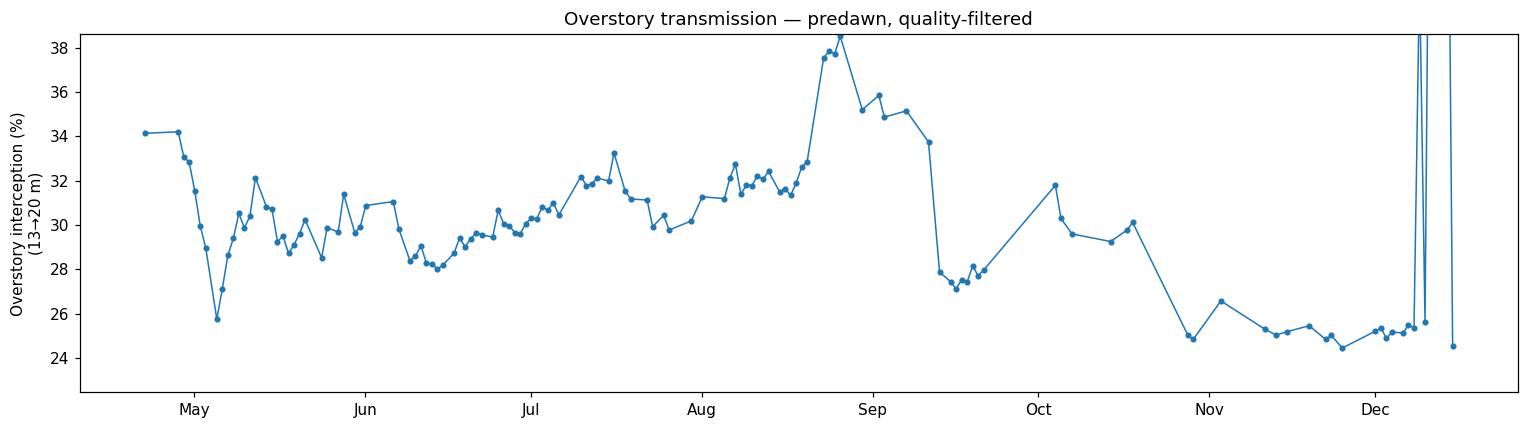

In [16]:
pgap_cols = [c for c in df.columns if c.startswith('Pgap_Z')]
predawn_good = df[(df.scan_hour == 2) & df.quality_good].copy()

p13 = predawn_good[predawn_good.height == 13.0].set_index('datetime')[pgap_cols].mean(axis=1)
p20 = predawn_good[predawn_good.height == 20.0].set_index('datetime')[pgap_cols].mean(axis=1)

ratio = (p20 / p13).dropna()
interception_pct = (1 - ratio) * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(interception_pct.index, interception_pct.values, 'o-', ms=3, lw=1)
ax.set(ylabel='Overstory interception (%)\n(13→20 m)',
       title='Overstory transmission — predawn, quality-filtered')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylim(np.nanpercentile(interception_pct.values, 0)-2, np.nanpercentile(interception_pct.values, 95)+2)
plt.tight_layout()
plt.show()

### Example 7: Compare scan types at the same hour

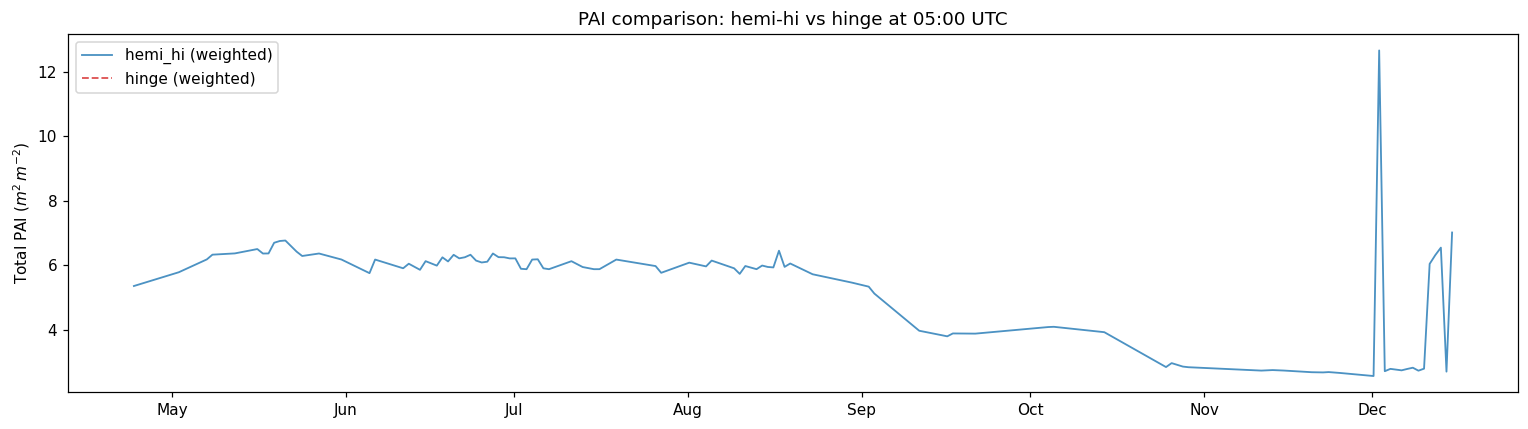

In [17]:
# Compare hinge vs hemi-hi total PAI at predawn
scan_hour = 5  # adjust to a common hour

fig, ax = plt.subplots(figsize=(14, 4))

for stype, color, ls in [('hemi_hi', '#1f77b4', '-'), ('hinge', '#d62728', '--')]:
    fp = OUT_DIR / f'leaf_{stype}_2025.parquet'
    if fp.exists():
        tmp = pd.read_parquet(fp)
        tmp['datetime'] = pd.to_datetime(tmp['datetime'])
        sel = tmp[(tmp.scan_hour == scan_hour) & tmp.quality_good]
        # Total PAI = max of WeightedPAI per scan
        pai = sel.groupby('datetime')['WeightedPAI'].max()
        ax.plot(pai.index, pai.values, color=color, ls=ls, lw=1.2,
                label=f'{stype} (weighted)', alpha=0.8)

ax.set(ylabel=r'Total PAI ($m^2\,m^{-2}$)',
       title=f'PAI comparison: hemi-hi vs hinge at {scan_hour:02d}:00 UTC')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

### Height-resolved interception heatmap

For each 1 m height layer, compute the **interception fraction**: what percentage of light reaching the layer bottom is absorbed before reaching the top.

$$\text{Interception}(h) = \left(1 - \frac{P_{gap}(h)}{P_{gap}(h - \Delta h)}\right) \times 100$$

Plotted as a heatmap with **time** (weekly median) on x and **height** on y.

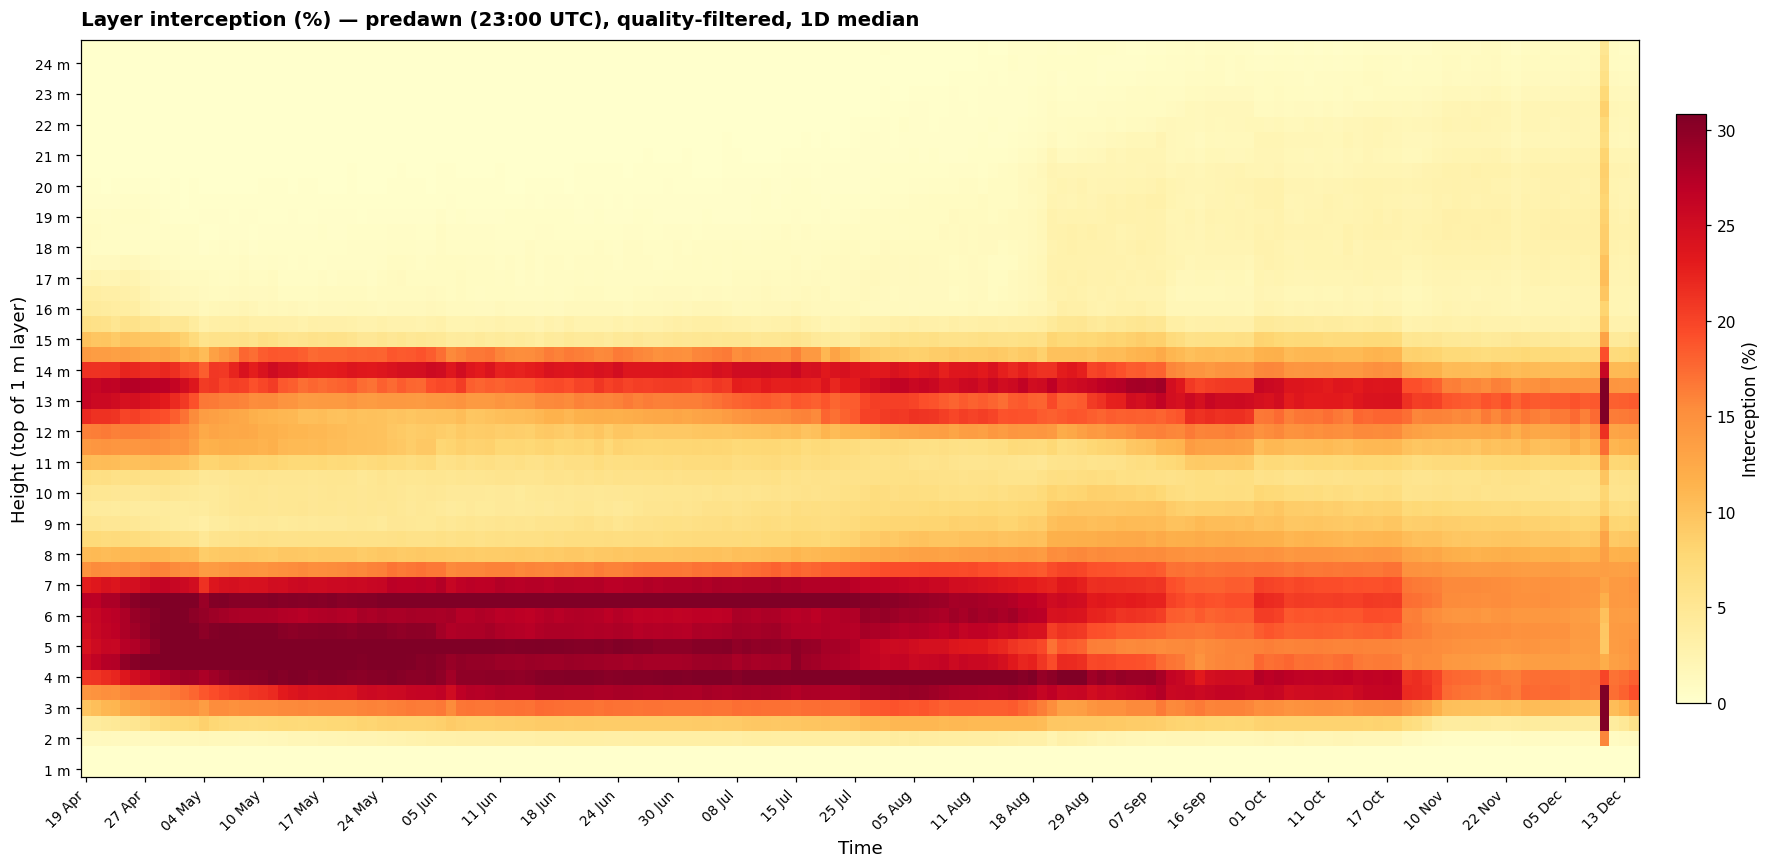

Scans used: 158
Time bins:  158 (1D median)
Height range: 1.0–24.5 m


In [22]:
# ── Height-resolved interception heatmap ───────────────────────────
# ▸ Change AGG_PERIOD to control temporal resolution:
#     '1D'  = 1 day
#     '2D'  = 2 days
#     '1W'  = 1 week  (ISO week, Mon–Sun)
#     '2W'  = 2 weeks
#     '1M'  = 1 month
AGG_PERIOD = '1D'

pgap_cols = sorted([c for c in df.columns if c.startswith('Pgap_Z')])

PREDAWN_HOUR = 23
predawn = df[(df.scan_hour == PREDAWN_HOUR) & df.quality_good].copy()

predawn['pgap_mean'] = predawn[pgap_cols].mean(axis=1)

pgap_pivot = predawn.pivot_table(
    values='pgap_mean', index='datetime', columns='height', aggfunc='median')

heights = sorted(pgap_pivot.columns)
pgap_pivot = pgap_pivot[heights]

layer_heights = [h for h in heights if h >= 1.0]
interception = pd.DataFrame(index=pgap_pivot.index)

for h in layer_heights:
    h_low = h - 1.0
    if h_low in pgap_pivot.columns and h in pgap_pivot.columns:
        p_low = pgap_pivot[h_low]
        p_high = pgap_pivot[h]
        ratio = (p_high / p_low).clip(upper=1.0)
        interception[h] = (1 - ratio) * 100

interception.index = pd.to_datetime(interception.index)

# Resample to chosen period and take median
agg = interception.resample(AGG_PERIOD).median().dropna(how='all')

# Build nice x-tick labels depending on period
def _make_xlabel(ts, period):
    if period.endswith('D'):
        return ts.strftime('%d %b')
    elif period.endswith('W'):
        return f"W{ts.isocalendar().week:02d}"
    else:
        return ts.strftime('%b')

x_labels = [_make_xlabel(ts, AGG_PERIOD) for ts in agg.index]

hmap = agg.T
hmap.index = hmap.index.astype(float)
hmap = hmap.sort_index()

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

im = ax.imshow(
    hmap.values, aspect='auto', origin='lower',
    cmap='YlOrRd', interpolation='nearest',
    vmin=np.nanpercentile(hmap.values, 2), vmax=np.nanpercentile(hmap.values, 98))

# x-axis
xtick_pos = np.arange(len(x_labels))
step = max(1, len(x_labels) // 25)
ax.set_xticks(xtick_pos[::step])
ax.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), step)],
                    rotation=45, ha='right', fontsize=9)

# y-axis
ytick_pos = np.arange(len(hmap.index))
ystep = 2
ax.set_yticks(ytick_pos[::ystep])
ax.set_yticklabels([f'{h:.0f} m' for h in hmap.index[::ystep]], fontsize=9)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Height (top of 1 m layer)', fontsize=12)
ax.set_title(
    f'Layer interception (%) — predawn ({PREDAWN_HOUR:02d}:00 UTC), '
    f'quality-filtered, {AGG_PERIOD} median',
    fontsize=13, fontweight='bold', loc='left', pad=10)

cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label('Interception (%)', fontsize=11)

fig.tight_layout()
plt.show()

print(f'Scans used: {len(predawn.datetime.unique())}')
print(f'Time bins:  {len(agg)} ({AGG_PERIOD} median)')
print(f'Height range: {hmap.index.min():.1f}–{hmap.index.max():.1f} m')